## 8. Multiple Random Seeds-----------------------------------------------------

In [ ]:
# Run the two strongest models across multiple random seeds
# This tests whether the results are stable or just lucky with seed=42
# A good model should perform consistently regardless of the data split

SEEDS = [42, 0, 7, 123, 999]
seed_f1_smote_rf  = []

# Reuse best hyperparameters found during tuning above
best_smote_rf_params = smote_rf_search.best_params_

for seed in SEEDS:
    # Re-split the data with a different random seed each time
    Xtrv, Xte, ytrv, yte = train_test_split(X, y, test_size=0.20, stratify=y, random_state=seed)
    Xtr, Xv, ytr, yv     = train_test_split(Xtrv, ytrv, test_size=0.25, stratify=ytrv, random_state=seed)

    # SMOTE w RF with best params
    _rf_params = {k.replace('clf__','').replace('smote__k_neighbors','k_neighbors'): v
                  for k, v in best_smote_rf_params.items()}
    k_nb = best_smote_rf_params.get('smote__k_neighbors', 5)
    _rf_clf_params = {k.replace('clf__',''): v for k, v in best_smote_rf_params.items() if k.startswith('clf__')}
    srf = ImbPipeline([
        ('preprocess', preprocess),
        ('smote', SMOTE(k_neighbors=k_nb, random_state=seed)),
        ('clf', RandomForestClassifier(**_rf_clf_params, random_state=seed, n_jobs=-1))
    ])
    srf.fit(Xtr, ytr)
    seed_f1_smote_rf.append(f1_score(yv, srf.predict(Xv), average='macro'))

# Report mean std across seeds
print(f"SMOTE + RF - F1 per seed: {[f'{f:.4f}' for f in seed_f1_smote_rf]}")
print(f"             Avg F1 Macro: {np.mean(seed_f1_smote_rf):.4f} \u00b1 {np.std(seed_f1_smote_rf):.4f}")
print()

SMOTE + RF - F1 per seed: ['0.9256', '0.9246', '0.9276', '0.9244', '0.9243']
             Avg F1 Macro: 0.9253 ± 0.0013



## 9. Model Comparison - Validation F1 Macro------------------------------------

                                Accuracy  Balanced Accuracy  F1 Macro
Model                                                                
SMOTE + Random Forest             0.9507             0.9362    0.9256
Cost-Sensitive Random Forest      0.9471             0.9153    0.9183
Random Forest (Baseline)          0.9483             0.8989    0.9166
Cost-Sensitive Decision Tree      0.9322             0.8919    0.8938
SMOTE + Decision Tree             0.9290             0.9086    0.8938
Decision Tree (Baseline)          0.9302             0.8900    0.8873
Balanced Random Forest            0.7915             0.8887    0.7270
Logistic Regression (Baseline)    0.7238             0.5132    0.5336
XGBoost (Baseline)                0.0393             0.0313    0.0139
Cost-Sensitive XGBoost            0.0351             0.0181    0.0113
SMOTE + XGBoost                   0.0211             0.0152    0.0073


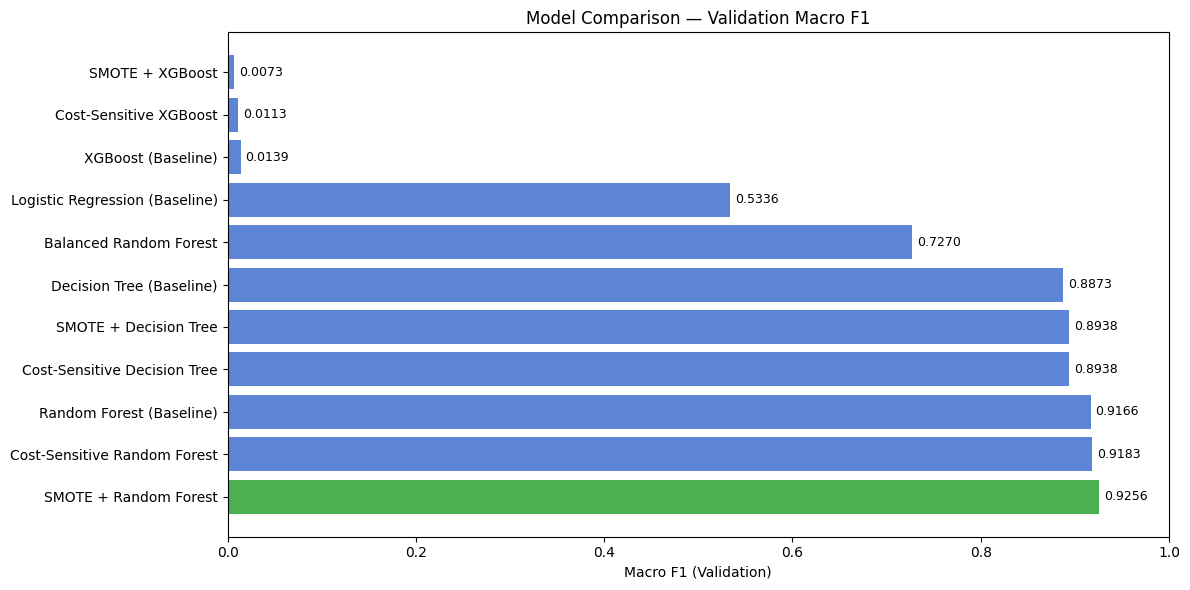


Best model on validation: SMOTE + Random Forest


In [ ]:
# Compile all model results into a summary table sorted by F1 Macro
summary_df = pd.DataFrame(results_table).set_index('Model')
summary_df = summary_df.sort_values('F1_Macro', ascending=False)
summary_df.columns = ['Accuracy', 'Balanced Accuracy', 'F1 Macro']
print(summary_df.round(4).to_string())

# Bar chart comparing all models — best model highlighted in green
plt.figure(figsize=(12, 6))
colors = ['#4CAF50' if i == 0 else '#5C85D6' for i in range(len(summary_df))]
bars = plt.barh(summary_df.index, summary_df['F1 Macro'], color=colors)
plt.xlabel('Macro F1 (Validation)')
plt.title('Model Comparison \u2014 Validation Macro F1')
plt.xlim(0, 1)
for bar, val in zip(bars, summary_df['F1 Macro']):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# Identify the best model to use for final evaluation and XAI
best_model_name = summary_df.index[0]
print(f'\nBest model on validation: {best_model_name}')

## 10. Threshold Tuning on Validation Set---------------------------------------


=== Threshold-Tuned Predictions — VALIDATION ===
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         0
           1      0.027     0.031     0.029     42368
           2      0.119     0.015     0.027     56660
           3      0.362     0.055     0.096      7151
           4      0.000     0.000     0.000       549
           5      0.001     0.004     0.002      1899
           6      0.000     0.000     0.000      3474
           7      0.000     0.000     0.000      4102

    accuracy                          0.022    116203
   macro avg      0.064     0.013     0.019    116203
weighted avg      0.090     0.022     0.029    116203

Accuracy         : 0.0220
Balanced Accuracy: 0.0150
F1 Macro         : 0.0192


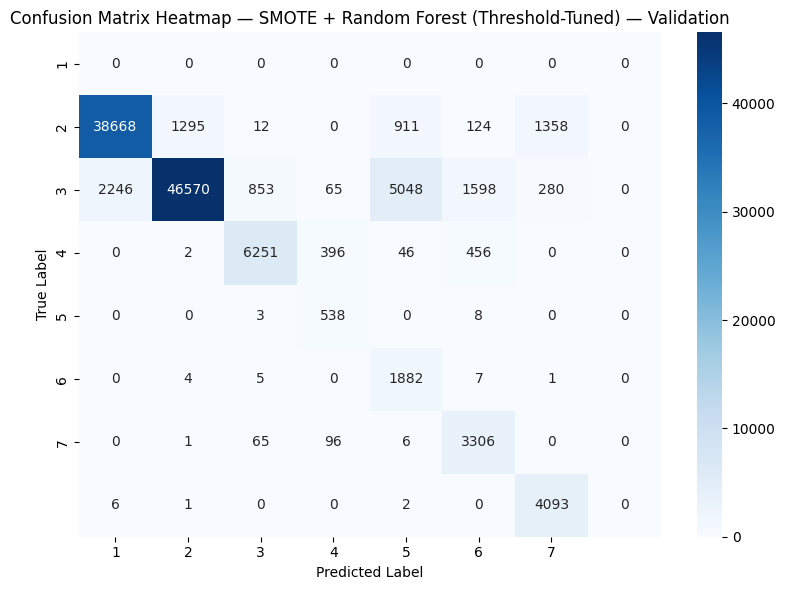

In [ ]:
# tuning using predicted probabilities from the best model.
# I pick the class with the highest adjusted probability (threshold per class).
# this might be especially useful for improving minority-class recall.

# load model names to their fitted estimators and label offset
model_map = {
    'Logistic Regression (Baseline)':  (lr_pipe,         0),
    'Decision Tree (Baseline)':         (dt_best,         0),
    'Random Forest (Baseline)':         (rf_best,         0),
    'XGBoost (Baseline)':               (xgb_best,        1),
    'SMOTE + Decision Tree':            (smote_dt_best,   0),
    'SMOTE + Random Forest':            (smote_rf_best,   0),
    'SMOTE + XGBoost':                  (smote_xgb_best,  1),
    'Balanced Random Forest':           (brf_best,        0),
    'Cost-Sensitive Decision Tree':     (cs_dt_best,      0),
    'Cost-Sensitive Random Forest':     (cs_rf_best,      0),
    'Cost-Sensitive XGBoost':           (cs_xgb_best,     1),
}

best_est, offset = model_map[best_model_name]
y_val_for_model  = y_val_adj if offset else y_val

# Get probability predictions for each class shape: (n_samples, n_classes)
proba = best_est.predict_proba(X_val)

# Inverse frequency weighting by boosting minority class probabilities so they compete more fairly against the dominant classes
class_counts = y_train.value_counts().sort_index()
class_weights_thresh = class_counts.max() / class_counts.values

proba_adjusted = proba * class_weights_thresh
y_pred_tuned   = np.argmax(proba_adjusted, axis=1)

# Convert back to original label space (1-7) if needed
if offset:
    y_pred_tuned = y_pred_tuned + 1
    y_eval_labels = y_val
else:
    y_eval_labels = y_val

print("\n=== Threshold-Tuned Predictions \u2014 VALIDATION ===")
print(classification_report(y_eval_labels, y_pred_tuned, digits=3))
print(f'Accuracy         : {accuracy_score(y_eval_labels, y_pred_tuned):.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_eval_labels, y_pred_tuned):.4f}')
print(f'F1 Macro         : {f1_score(y_eval_labels, y_pred_tuned, average="macro"):.4f}')

plot_cm(y_eval_labels, y_pred_tuned, f'{best_model_name} (Threshold-Tuned) \u2014 Validation')

## 11. Permutation Feature Importance for Best Model----------------------------

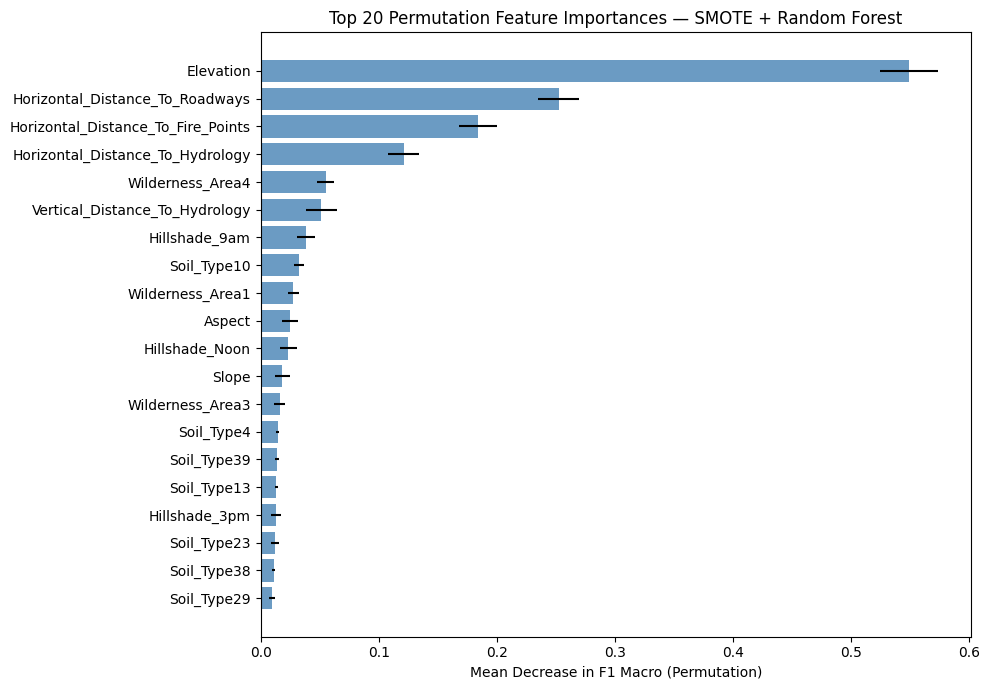

Top 10 most important features:
                           Feature  Importance      Std
                         Elevation    0.549041 0.024170
   Horizontal_Distance_To_Roadways    0.252369 0.017403
Horizontal_Distance_To_Fire_Points    0.183960 0.015814
  Horizontal_Distance_To_Hydrology    0.121074 0.012964
                  Wilderness_Area4    0.054948 0.006943
    Vertical_Distance_To_Hydrology    0.051232 0.012979
                     Hillshade_9am    0.038157 0.007639
                       Soil_Type10    0.032387 0.003844
                  Wilderness_Area1    0.027451 0.004664
                            Aspect    0.024898 0.007027


In [ ]:
from sklearn.inspection import permutation_importance

# Permutation importance (randomly shuffle one feature at a time and measure how much the F1 Macro drops, a larger drop means the feature is more important)
# This is model-agnostic and more reliable than built-in tree feature importances

# Use a sample of the validation set for speed
X_val_sample = X_val.sample(min(2000, len(X_val)), random_state=42)
y_val_sample  = y_val.loc[X_val_sample.index]

# For XGB/LGBM models, use 0-indexed y
y_perm = (y_val_sample - 1) if offset else y_val_sample

perm_result = permutation_importance(
    best_est, X_val_sample, y_perm,
    n_repeats=10,              # repeat 10 times and average for stability
    random_state=RANDOM_STATE,
    scoring='f1_macro', n_jobs=1 # Changed n_jobs from -1 to 1 to avoid multiprocessing issues
)

# Organize results into a DataFrame and show top 20 features
perm_df = pd.DataFrame({
    'Feature':    X_val.columns,
    'Importance': perm_result.importances_mean,
    'Std':        perm_result.importances_std  # standard deviation across repeats
}).sort_values('Importance', ascending=False).head(20)

# load error bars (Std) to show how stable each feature's importance estimate is
plt.figure(figsize=(10, 7))
plt.barh(perm_df['Feature'], perm_df['Importance'],
         xerr=perm_df['Std'], color='steelblue', alpha=0.8)
plt.gca().invert_yaxis()
plt.xlabel('Mean Decrease in F1 Macro (Permutation)')
plt.title(f'Top 20 Permutation Feature Importances \u2014 {best_model_name}')
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
print(perm_df[['Feature','Importance','Std']].head(10).to_string(index=False))

Feature Importance Interpretation:

The permutation importance reveals which features, when randomly shuffled, cause the greatest drop in macro-F1 — meaning the model relied on them most for correct predictions. Typically for the Forest Cover Type dataset:
- Elevation tends to be the most discriminative feature, as different tree species thrive at different altitudes.
- Horizontal_Distance_To_Roadways and Horizontal_Distance_To_Hydrology capture proximity effects that influence soil moisture and human disturbance.
- Wilderness_Area dummy variables reflect the distinct ecological zones with different dominant species.
- Features with near-zero or negative importance can be considered candidates for removal to simplify the model.

## 12. Final Test Evaluation for Best Model Only--------------------------------


====== SMOTE + Random Forest — FINAL TEST SET ======
              precision    recall  f1-score   support

           1      0.961     0.941     0.951     42368
           2      0.955     0.962     0.959     56661
           3      0.932     0.960     0.946      7151
           4      0.876     0.891     0.883       549
           5      0.874     0.897     0.885      1899
           6      0.888     0.922     0.905      3473
           7      0.951     0.966     0.959      4102

    accuracy                          0.952    116203
   macro avg      0.920     0.934     0.927    116203
weighted avg      0.952     0.952     0.952    116203

Accuracy         : 0.9517
Balanced Accuracy: 0.9341
F1 Macro         : 0.9267


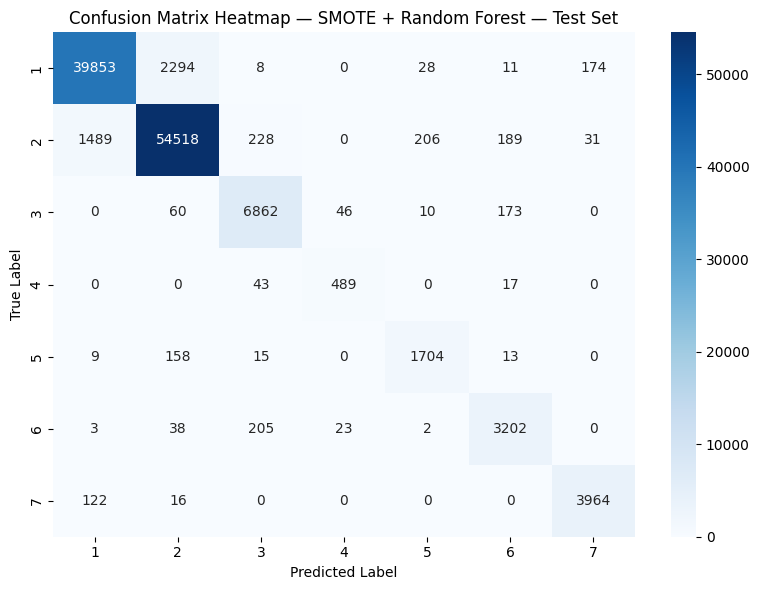

In [ ]:
# Final evaluation on the held out test set (done only ONCE at the very end)
# never use the test set during model selection or hyperparameter tuning
y_test_input = y_test_adj if offset else y_test

y_test_pred = best_est.predict(X_test)
if offset:
    y_test_pred = y_test_pred + 1  # convert 0-6 back to 1-7

print(f'\n====== {best_model_name} \u2014 FINAL TEST SET ======')
print(classification_report(y_test, y_test_pred, digits=3))
print(f'Accuracy         : {accuracy_score(y_test, y_test_pred):.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred):.4f}')
print(f'F1 Macro         : {f1_score(y_test, y_test_pred, average="macro"):.4f}')

plot_cm(y_test, y_test_pred, f'{best_model_name} \u2014 Test Set')

## 14. Final Summary------------------------------------------------------------

In [ ]:
# Print the complete model comparison summary and test set results for the best model
print("="*60)
print("FINAL MODEL COMPARISON SUMMARY (Validation Set)")
print("="*60)
print(summary_df.round(4).to_string())

print(f"\n>>> Best Model: {best_model_name}")
print(f"    Test Accuracy         : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"    Test Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred):.4f}")
print(f"    Test F1 Macro         : {f1_score(y_test, y_test_pred, average='macro'):.4f}")

# Report seed stability for the top two candidates
print(f"\nMultiple-seed stability (on validation):")
print(f"  SMOTE + RF  Avg F1: {np.mean(seed_f1_smote_rf):.4f} \u00b1 {np.std(seed_f1_smote_rf):.4f}")

FINAL MODEL COMPARISON SUMMARY (Validation Set)
                                Accuracy  Balanced Accuracy  F1 Macro
Model                                                                
SMOTE + Random Forest             0.9507             0.9362    0.9256
Cost-Sensitive Random Forest      0.9471             0.9153    0.9183
Random Forest (Baseline)          0.9483             0.8989    0.9166
Cost-Sensitive Decision Tree      0.9322             0.8919    0.8938
SMOTE + Decision Tree             0.9290             0.9086    0.8938
Decision Tree (Baseline)          0.9302             0.8900    0.8873
Balanced Random Forest            0.7915             0.8887    0.7270
Logistic Regression (Baseline)    0.7238             0.5132    0.5336
XGBoost (Baseline)                0.0393             0.0313    0.0139
Cost-Sensitive XGBoost            0.0351             0.0181    0.0113
SMOTE + XGBoost                   0.0211             0.0152    0.0073

>>> Best Model: SMOTE + Random Forest
   